# F1 Model Analysis
Error analysis across all four models: where do they fail and why.

In [1]:
import sys, os, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sys.path.insert(0, ".")
from models import LinearRegressionModel, XGBoostModel, GRUModel, TFTModel
from models.config import (
    DATA_PATH, TARGET_COL, TEST_YEARS, IMAGE_PATH,
    HIST_CAT_COLS, FLAT_FEATURE_COLS, GROUP_COLS,
    STATIC_NUM_COLS, HIST_NUM_COLS, FUTURE_NUM_COLS,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

df_full = pd.read_csv(DATA_PATH)
df_test = df_full[df_full["year"].isin(TEST_YEARS)].dropna(subset=[TARGET_COL]).reset_index(drop=True)

print(f"Full dataset: {len(df_full):,} rows | Test set: {len(df_test):,} rows")

/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


Full dataset: 191,015 rows | Test set: 26,657 rows


## Load Models

In [2]:
lr_model  = LinearRegressionModel.load()
xgb_model = XGBoostModel.load()
gru_model = GRUModel.load()
tft_model = TFTModel.load()

print("All models loaded.")

All models loaded.


In [3]:
GRU_CAT_COLS = [c for c in HIST_CAT_COLS if c != "pit_lap"]
GRU_NUM_COLS = [c for c in FLAT_FEATURE_COLS if c not in set(GRU_CAT_COLS)]


def predict_lr_aligned(model, df):
    preds = model.predict(df)
    return pd.Series(preds, index=df.index, name="lr")


def predict_xgb_aligned(model, df):
    preds = model.predict(df)
    return pd.Series(preds, index=df.index, name="xgb")


def predict_gru_aligned(model, df):
    arts = model._artifacts
    seq_len = arts["sequence_length"]
    cat_cols = [c for c in GRU_CAT_COLS if c in df.columns]
    num_cols = [c for c in GRU_NUM_COLS if c in df.columns]
    feature_cols = cat_cols + num_cols

    df2 = df.copy()
    for col in num_cols:
        df2[col] = df2.groupby(["year", "round_number", "driver"])[col].transform(
            lambda x: x.fillna(x.median())
        )
    df2 = df2.fillna(0)
    for col in cat_cols:
        df2[col] = arts["label_encoders"][col].transform(df2[col].astype(str))

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model._net.to(device).eval()

    idx_list, pred_list = [], []
    for _, grp in df2.groupby(["year", "round_number", "driver"]):
        if len(grp) < seq_len + 1:
            continue
        grp = grp.sort_values("number")
        feats = arts["feature_scaler"].transform(grp[feature_cols].values.astype(np.float32))
        seqs = [feats[i: i + seq_len] for i in range(len(grp) - seq_len)]
        X = torch.tensor(np.array(seqs, dtype=np.float32)).to(device)
        with torch.no_grad():
            raw = model._net(X).cpu().numpy()
        preds = arts["target_scaler"].inverse_transform(raw.reshape(-1, 1)).flatten()
        idx_list.extend(grp.index[seq_len:])
        pred_list.extend(preds)

    return pd.Series(pred_list, index=idx_list, name="gru").sort_index()


def predict_tft_aligned(model, df):
    arts = model._artifacts
    hp = arts["hyperparams"]
    history_len = hp.get("history_len", 20)
    future_len = hp.get("future_len", 5)
    total_len = history_len + future_len
    target_sc = arts["scalers"][TARGET_COL]

    from models.config import STATIC_CAT_COLS, HIST_CAT_COLS as _HCAT, FUTURE_CAT_COLS, FUTURE_NUM_COLS as _FN
    df2 = df.sort_values(GROUP_COLS + ["number"]).copy().reset_index()
    df2.rename(columns={"index": "orig_idx"}, inplace=True)

    for c in STATIC_CAT_COLS + HIST_CAT_COLS:
        if c in df2.columns:
            df2[c] = df2[c].fillna("UNKNOWN").astype(str)
    df2["pit_lap"] = (
        pd.to_numeric(df2["pit_lap"], errors="coerce")
        .fillna(0).clip(0, 2).astype(int).astype(str)
    )
    for c in set(HIST_NUM_COLS + _FN):
        if c in df2.columns:
            df2[c] = pd.to_numeric(df2[c], errors="coerce")
            df2[c] = df2.groupby(GROUP_COLS)[c].transform(lambda x: x.ffill().bfill())
    for c in STATIC_NUM_COLS + HIST_NUM_COLS + _FN:
        if c in df2.columns:
            df2[c] = df2[c].fillna(df2[c].median())

    for c, le in arts["encoders"].items():
        if c in df2.columns:
            df2[f"{c}_enc"] = le.transform(df2[c].astype(str))
    for c, sc in arts["scalers"].items():
        if c in df2.columns:
            lo, hi = arts["clip_bounds"][c]
            clipped = df2[c].clip(lower=lo, upper=hi).values
            df2[f"{c}_sc"] = sc.transform(clipped.reshape(-1, 1)).flatten()

    sn_cols = [f"{c}_sc" for c in STATIC_NUM_COLS]
    hn_cols = [f"{c}_sc" for c in HIST_NUM_COLS]
    hc_cols = [f"{c}_enc" for c in HIST_CAT_COLS]
    fn_cols = [f"{c}_sc" for c in _FN]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model._net.to(device).eval()

    idx_list, pred_list = [], []
    for _, grp in df2.groupby(GROUP_COLS, sort=False):
        if len(grp) < total_len:
            continue
        grp = grp.reset_index(drop=True)
        for w in range(len(grp) - total_len + 1):
            h = grp.iloc[w: w + history_len]
            f = grp.iloc[w + history_len: w + total_len]
            static_n = torch.FloatTensor(h.iloc[0][sn_cols].values.astype(np.float32)).unsqueeze(0)
            static_c = torch.zeros(1, 0, dtype=torch.long)
            hist_n   = torch.FloatTensor(h[hn_cols].values.astype(np.float32)).unsqueeze(0)
            hist_c   = torch.LongTensor(h[hc_cols].values.astype(np.int32)).unsqueeze(0)
            fut_n    = torch.FloatTensor(f[fn_cols].values.astype(np.float32)).unsqueeze(0)
            batch = {
                "static_feats_numeric": static_n.to(device),
                "static_feats_categorical": static_c.to(device),
                "historical_ts_numeric": hist_n.to(device),
                "historical_ts_categorical": hist_c.to(device),
                "future_ts_numeric": fut_n.to(device),
            }
            with torch.no_grad():
                out = model._net(batch)
            pred_scaled = out["predicted_quantiles"][0, 0, 1].cpu().item()
            pred_inv = target_sc.inverse_transform([[pred_scaled]])[0, 0]
            idx_list.append(grp.iloc[w + history_len]["orig_idx"])
            pred_list.append(pred_inv)

    return pd.Series(pred_list, index=idx_list, name="tft").sort_index()


print("Generating predictions on test set...")
pred_lr  = predict_lr_aligned(lr_model, df_test)
pred_xgb = predict_xgb_aligned(xgb_model, df_test)
pred_gru = predict_gru_aligned(gru_model, df_test)
pred_tft = predict_tft_aligned(tft_model, df_test)

df_preds = df_test.copy()
df_preds["pred_lr"]  = pred_lr
df_preds["pred_xgb"] = pred_xgb
df_preds["pred_gru"] = pred_gru
df_preds["pred_tft"] = pred_tft

for m in ["lr", "xgb", "gru", "tft"]:
    df_preds[f"resid_{m}"]  = df_preds[f"pred_{m}"] - df_preds[TARGET_COL]
    df_preds[f"abserr_{m}"] = df_preds[f"resid_{m}"].abs()

print(f"Done. Rows with all 4 models: {df_preds[['pred_lr','pred_xgb','pred_gru','pred_tft']].dropna().shape[0]:,}")

Generating predictions on test set...
Done. Rows with all 4 models: 17,507


## 1. Overall Metrics

In [5]:
def metrics_row(y_true, y_pred, name):
    mask = (~np.isnan(y_true)) & (~np.isnan(y_pred))
    y_t, y_p = y_true[mask], y_pred[mask]
    rmse = float(np.sqrt(mean_squared_error(y_t, y_p)))
    mae = float(mean_absolute_error(y_t, y_p))
    r2 = float(r2_score(y_t, y_p))
    p95 = float(np.percentile(np.abs(y_p - y_t), 95))
    return {"model": name, "n": int(mask.sum()), "RMSE": rmse, "MAE": mae, "R²": r2, "p95_abs_err": p95}


y_true = df_preds[TARGET_COL].values
rows = [
    metrics_row(y_true, df_preds["pred_lr"].values, "LinearRegression"),
    metrics_row(y_true, df_preds["pred_xgb"].values, "XGBoost"),
    metrics_row(y_true, df_preds["pred_gru"].values, "GRU"),
    metrics_row(y_true, df_preds["pred_tft"].values, "TFT"),
]

metrics_df = pd.DataFrame(rows).set_index("model")
metrics_df.index.name = None

styled = (
    metrics_df.style
    .highlight_min(subset=["RMSE", "MAE", "p95_abs_err"], color="lightgreen")
    .highlight_max(subset=["R²"], color="lightgreen")
    .format({"RMSE": "{:.4f}", "MAE": "{:.4f}", "R²": "{:.4f}", "p95_abs_err": "{:.4f}"})
)

import dataframe_image as dfi
dfi.export(styled, os.path.join(IMAGE_PATH, "metrics_table.png"), dpi=150, table_conversion='matplotlib')

styled


,n,RMSE,MAE,R²,p95_abs_err
LinearRegression,26657,8.7412,6.4792,-1.3405,17.2223
XGBoost,26657,11.4005,2.0376,-2.9813,6.6969
GRU,20235,6.1070,3.3375,-0.0280,11.8450
TFT,19324,4.5423,1.5062,0.4234,5.9833


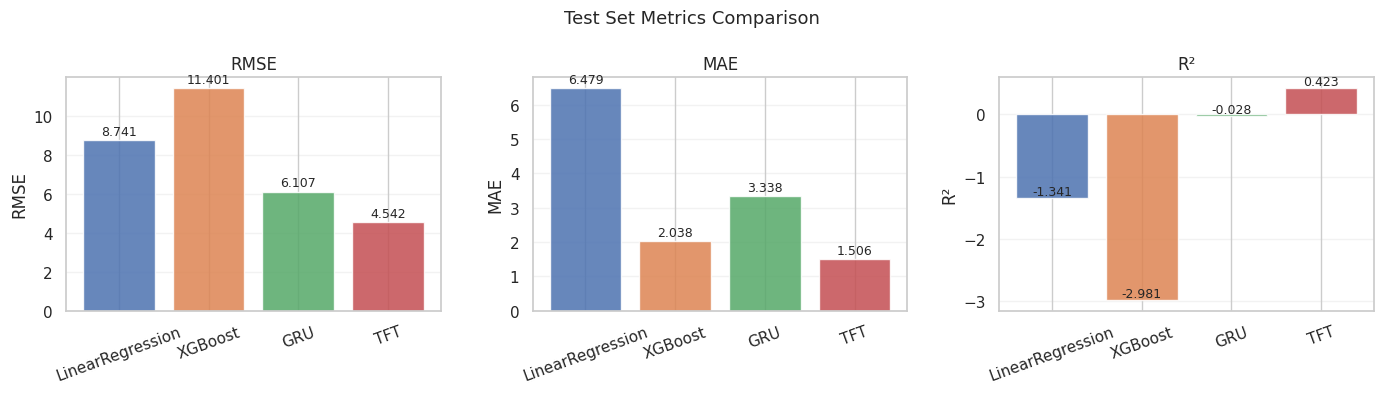

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Test Set Metrics Comparison", fontsize=13)

model_names = metrics_df.index.tolist()
colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52"]

for ax, metric in zip(axes, ["RMSE", "MAE", "R²"]):
    vals = metrics_df[metric].values
    bars = ax.bar(model_names, vals, color=colors, alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(True, axis="y", alpha=0.25)

plt.tight_layout()
fig.savefig(os.path.join(IMAGE_PATH, "metrics_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## 2. Residual Distributions

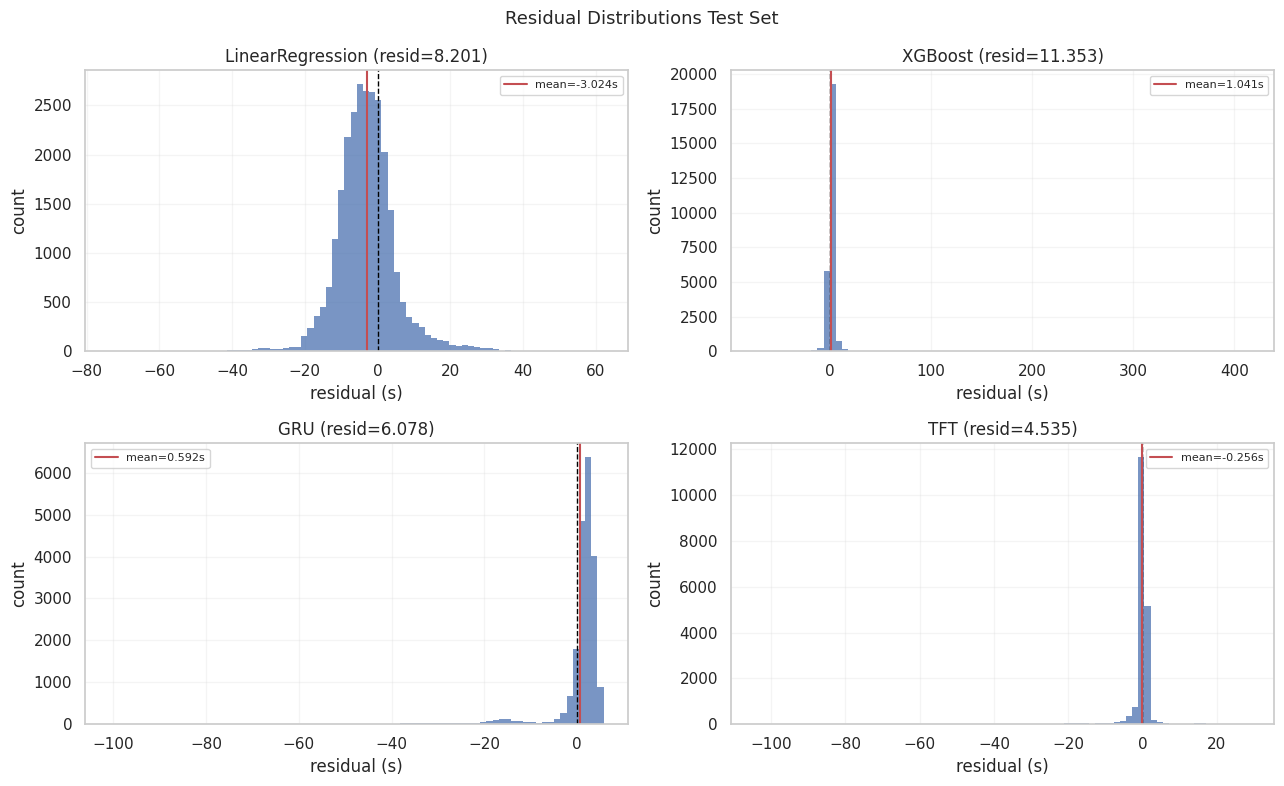

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Residual Distributions Test Set", fontsize=13)

model_labels = [("lr", "LinearRegression"), ("xgb", "XGBoost"), ("gru", "GRU"), ("tft", "TFT")]

for ax, (key, label) in zip(axes.flat, model_labels):
    resid = df_preds[f"resid_{key}"].dropna().values
    ax.hist(resid, bins=80, color="#4c72b0", edgecolor="none", alpha=0.75)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.axvline(resid.mean(), color="#c44e52", linestyle="-", linewidth=1.5, label=f"mean={resid.mean():.3f}s")
    ax.set_title(f"{label} (resid={resid.std():.3f})")
    ax.set_xlabel("residual (s)")
    ax.set_ylabel("count")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
fig.savefig(os.path.join(IMAGE_PATH, "residual_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()

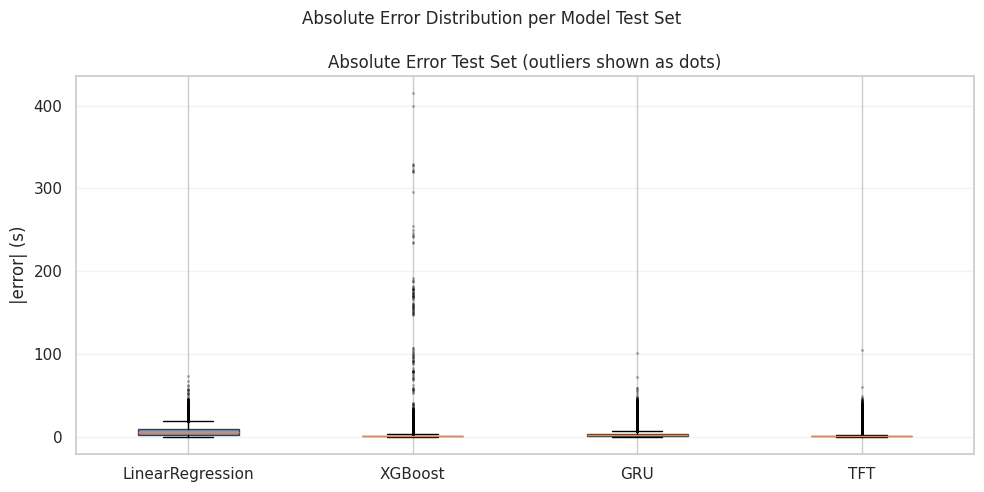

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Absolute Error Distribution per Model Test Set", fontsize=12)

data_to_plot = [df_preds[f"abserr_{k}"].dropna().values for k, _ in model_labels]
bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False, showfliers=True,
                flierprops=dict(marker=".", markersize=2, alpha=0.3))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticklabels([l for _, l in model_labels])
ax.set_ylabel("|error| (s)")
ax.set_title("Absolute Error Test Set (outliers shown as dots)")
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
fig.savefig(os.path.join(IMAGE_PATH, "absolute_error_boxplot.png"), dpi=150, bbox_inches="tight")
plt.show()

## 3. Error by Race Context

### 3.1 Pit Stop Laps

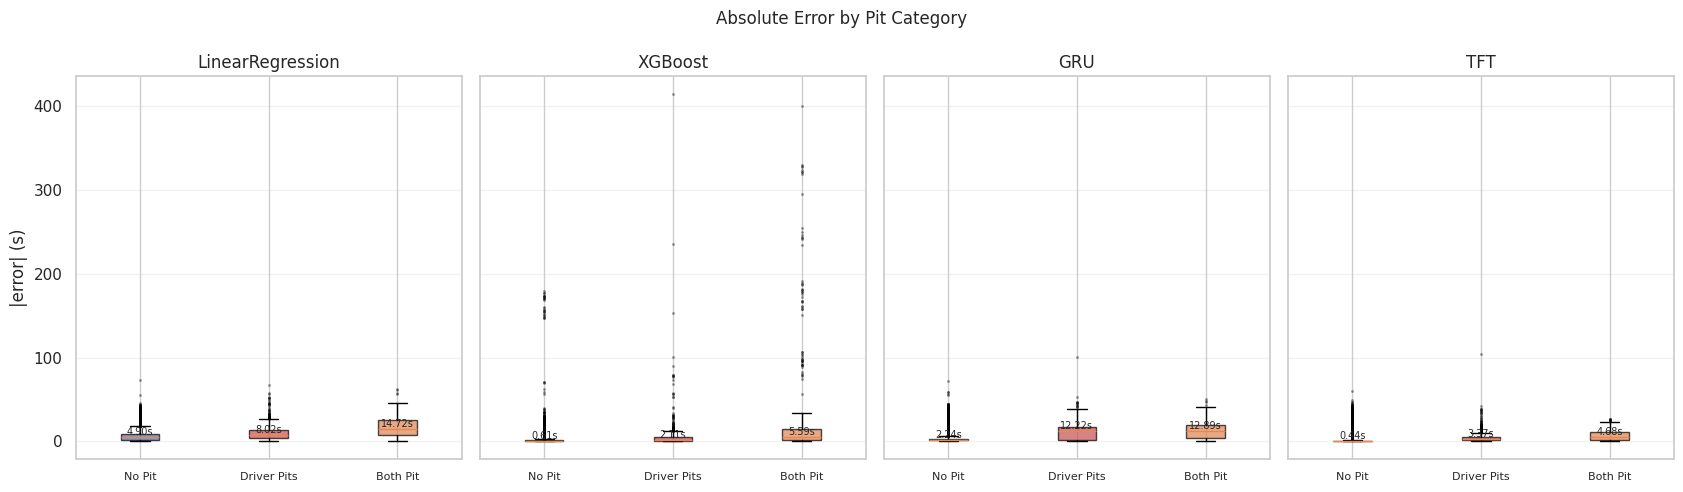


LinearRegression:
no_pit                        : MAE=6.135s  n=25,089
pit_leader_no_pit             : MAE=10.064s  n=1,116
pit_leader_also_pits          : MAE=16.741s  n=452

XGBoost:
no_pit                        : MAE=1.405s  n=25,089
pit_leader_no_pit             : MAE=5.612s  n=1,116
pit_leader_also_pits          : MAE=28.351s  n=452

GRU:
no_pit                        : MAE=2.808s  n=19,026
pit_leader_no_pit             : MAE=10.971s  n=869
pit_leader_also_pits          : MAE=13.446s  n=340

TFT:
no_pit                        : MAE=1.182s  n=18,065
pit_leader_no_pit             : MAE=5.875s  n=936
pit_leader_also_pits          : MAE=6.975s  n=323


In [9]:
leader_per_lap = (
    df_test[df_test["gap_from_leader"] == 0]
    .set_index(["round_number", "number"])[["pit_lap"]]
    .rename(columns={"pit_lap": "leader_pit_lap"})
)
df_ctx = df_test.join(leader_per_lap, on=["round_number", "number"])
df_ctx["pit_category"] = "no_pit"
df_ctx.loc[df_ctx["pit_lap"] > 0, "pit_category"] = "pit_leader_no_pit"
df_ctx.loc[
    (df_ctx["pit_lap"] > 0) & (df_ctx["leader_pit_lap"] > 0),
    "pit_category"
] = "pit_leader_also_pits"

fig, axes = plt.subplots(1, 4, figsize=(17, 5), sharey=True)
fig.suptitle("Absolute Error by Pit Category", fontsize=12)

for ax, (key, label) in zip(axes, model_labels):
    abserr = df_preds[f"abserr_{key}"].reindex(df_ctx.index)
    grouped = df_ctx.groupby("pit_category").apply(lambda g: abserr.loc[g.index].dropna())
    categories = ["no_pit", "pit_leader_no_pit", "pit_leader_also_pits"]
    cat_labels = ["No Pit", "Driver Pits", "Both Pit"]
    data_bp = [grouped.get(c, pd.Series(dtype=float)).values for c in categories]
    bp = ax.boxplot(data_bp, patch_artist=True, showfliers=True,
                    flierprops=dict(marker=".", markersize=2, alpha=0.4))
    for patch, color in zip(bp["boxes"], ["#4c72b0", "#c44e52", "#dd8452"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for i, data in enumerate(data_bp):
        if len(data) > 0:
            ax.text(i + 1, np.median(data), f"{np.median(data):.2f}s",
                    ha="center", va="bottom", fontsize=7)
    ax.set_xticklabels(cat_labels, fontsize=8)
    ax.set_title(label)
    ax.grid(True, axis="y", alpha=0.25)
    if ax == axes[0]:
        ax.set_ylabel("|error| (s)")

plt.tight_layout()
fig.savefig(os.path.join(IMAGE_PATH, "error_by_pit_category.png"), dpi=150, bbox_inches="tight")
plt.show()

for key, label in model_labels:
    abserr = df_preds[f"abserr_{key}"].reindex(df_ctx.index)
    print(f"\n{label}:")
    for cat in ["no_pit", "pit_leader_no_pit", "pit_leader_also_pits"]:
        mask = df_ctx["pit_category"] == cat
        vals = abserr.loc[df_ctx.index[mask]].dropna()
        if len(vals):
            print(f"{cat:<30}: MAE={vals.mean():.3f}s  n={len(vals):,}")

### 3.2 Flag / Safety Car Laps

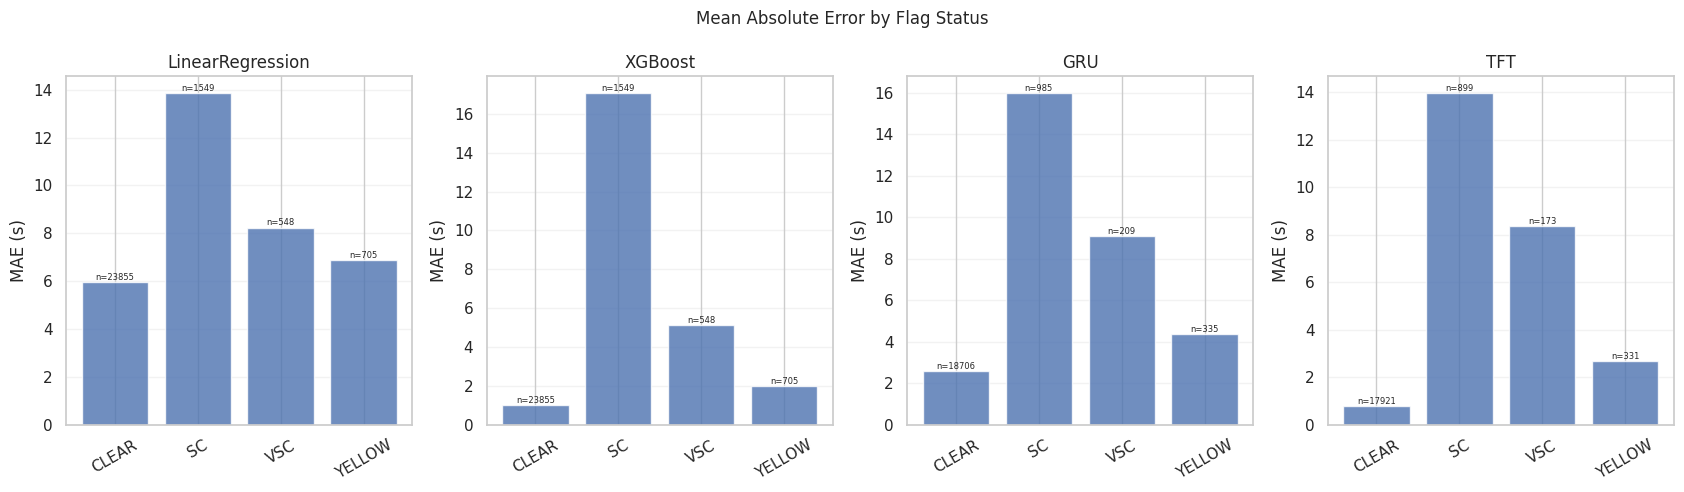

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(17, 5))
fig.suptitle("Mean Absolute Error by Flag Status", fontsize=12)

flag_order = sorted(df_test["flag"].dropna().unique())

for ax, (key, label) in zip(axes, model_labels):
    abserr = df_preds[f"abserr_{key}"]
    flag_mae = (
        df_test.assign(abserr=abserr)
        .groupby("flag")["abserr"]
        .agg(["mean", "count"])
        .reindex(flag_order)
    )
    bar_colors = ["#c44e52" if "safety" in str(f).lower() or "red" in str(f).lower()
                  else "#4c72b0" for f in flag_order]
    bars = ax.bar(flag_order, flag_mae["mean"], color=bar_colors, alpha=0.8, edgecolor="white")
    for bar, (_, row) in zip(bars, flag_mae.iterrows()):
        if not np.isnan(row["mean"]):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"n={int(row['count'])}", ha="center", va="bottom", fontsize=6)
    ax.set_title(label)
    ax.set_ylabel("MAE (s)")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, axis="y", alpha=0.25)

plt.tight_layout()
fig.savefig(os.path.join(IMAGE_PATH, "error_by_flag.png"), dpi=150, bbox_inches="tight")
plt.show()

### 3.3 Tyre Age Bins

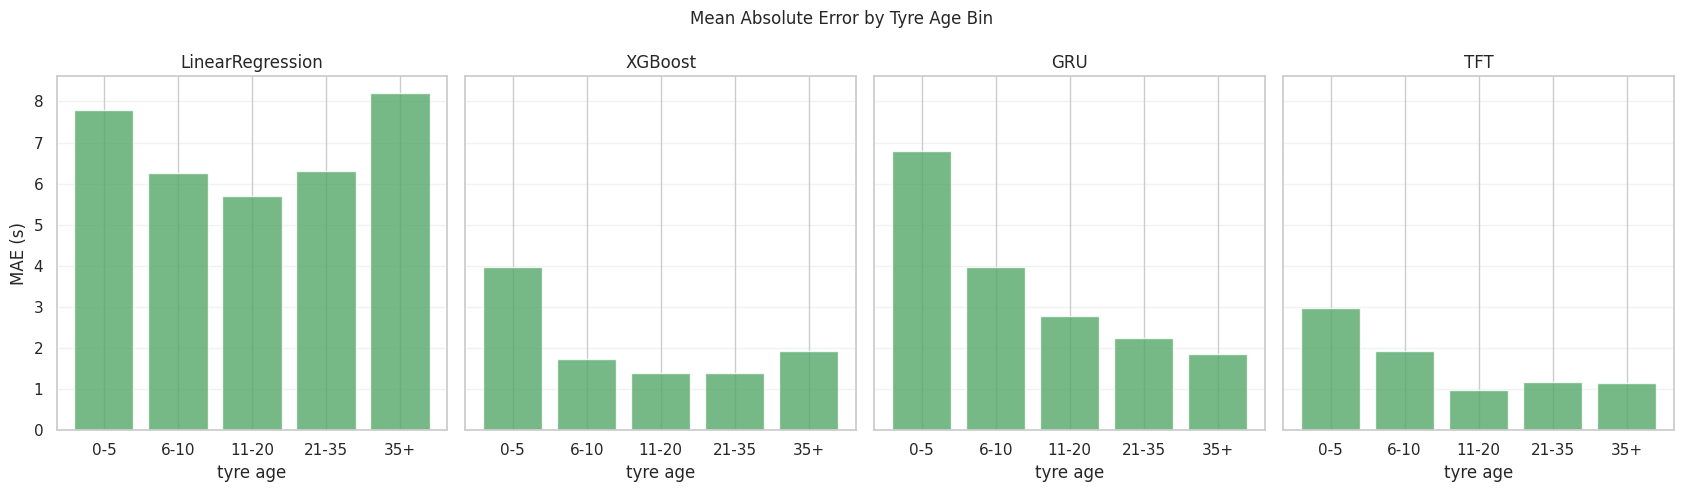

In [11]:
df_test["tyre_age_bin"] = pd.cut(df_test["tyre_age"], bins=[0, 5, 10, 20, 35, 100],
                                 labels=["0-5", "6-10", "11-20", "21-35", "35+"])

fig, axes = plt.subplots(1, 4, figsize=(17, 5), sharey=True)
fig.suptitle("Mean Absolute Error by Tyre Age Bin", fontsize=12)

for ax, (key, label) in zip(axes, model_labels):
    abserr = df_preds[f"abserr_{key}"]
    age_mae = df_test.assign(abserr=abserr).groupby("tyre_age_bin", observed=True)["abserr"].mean()
    ax.bar(age_mae.index.astype(str), age_mae.values, color="#55a868", alpha=0.8, edgecolor="white")
    ax.set_title(label)
    ax.set_xlabel("tyre age")
    if ax == axes[0]:
        ax.set_ylabel("MAE (s)")
    ax.grid(True, axis="y", alpha=0.25)

plt.tight_layout()
fig.savefig(os.path.join(IMAGE_PATH, "error_by_tyre_age.png"), dpi=150, bbox_inches="tight")
plt.show()

### 3.5 Compound

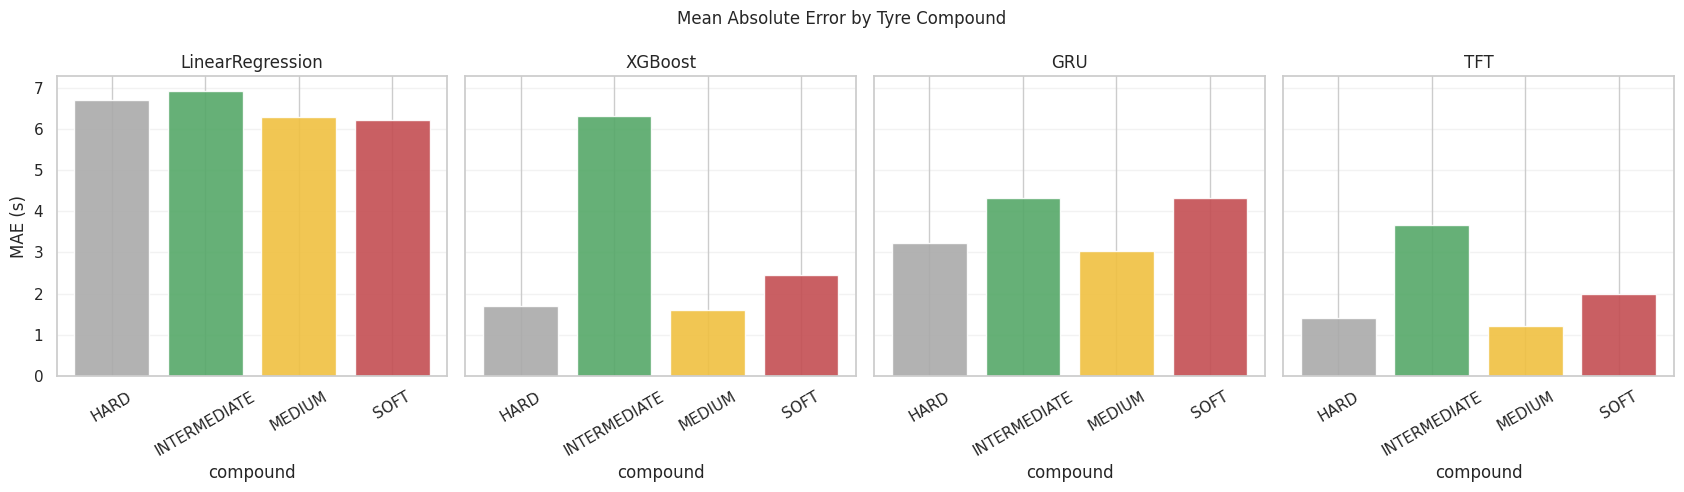

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(17, 5), sharey=True)
fig.suptitle("Mean Absolute Error by Tyre Compound", fontsize=12)

compound_colors = {"SOFT": "#c44e52", "MEDIUM": "#f0c040", "HARD": "#aaaaaa",
                   "INTERMEDIATE": "#55a868", "WET": "#4c72b0"}
compounds = sorted(df_test["compound"].dropna().unique())

for ax, (key, label) in zip(axes, model_labels):
    abserr = df_preds[f"abserr_{key}"]
    comp_mae = df_test.assign(abserr=abserr).groupby("compound")["abserr"].mean().reindex(compounds)
    bar_colors = [compound_colors.get(c, "#777777") for c in compounds]
    ax.bar(compounds, comp_mae.values, color=bar_colors, alpha=0.9, edgecolor="white")
    ax.set_title(label)
    ax.set_xlabel("compound")
    ax.tick_params(axis="x", rotation=30)
    if ax == axes[0]:
        ax.set_ylabel("MAE (s)")
    ax.grid(True, axis="y", alpha=0.25)

plt.tight_layout()
fig.savefig(os.path.join(IMAGE_PATH, "error_by_compound.png"), dpi=150, bbox_inches="tight")
plt.show()

### 3.6 Lap Number Progression

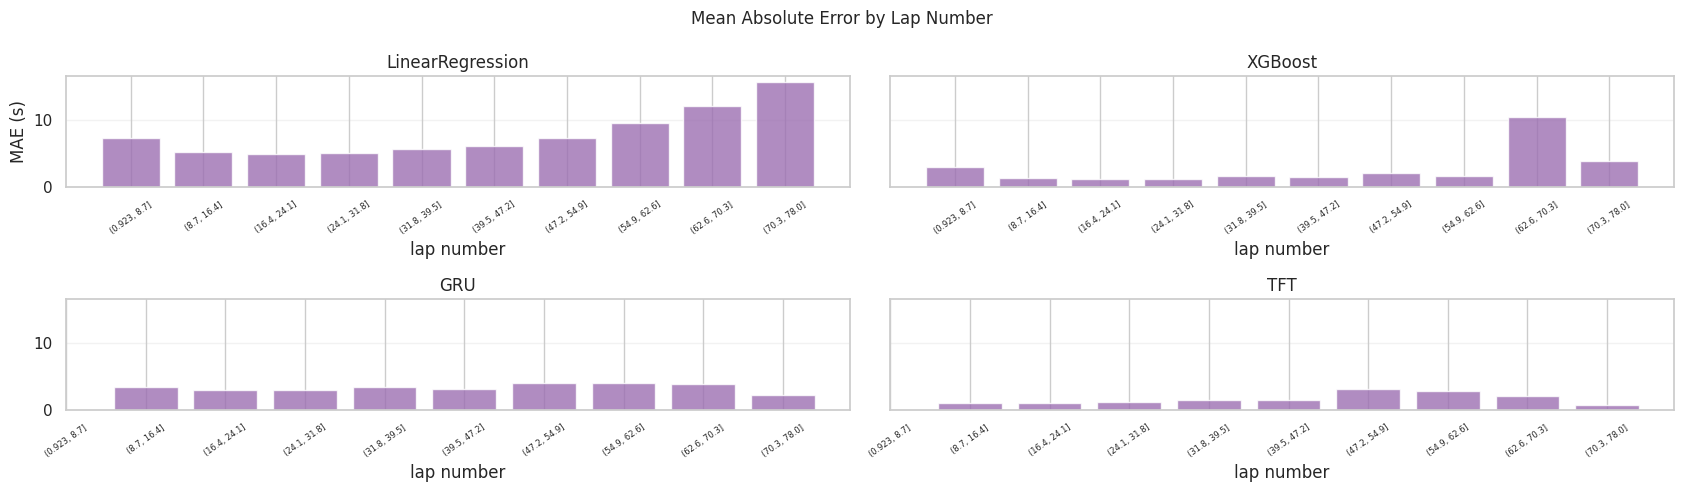

In [13]:
# Bin by lap number within race
df_test["lap_bin"] = pd.cut(df_test["number"], bins=10)

fig, axes = plt.subplots(2, 2, figsize=(17, 5), sharey=True)
fig.suptitle("Mean Absolute Error by Lap Number", fontsize=12)

for ax, (key, label) in zip(axes.flat, model_labels):
    abserr = df_preds[f"abserr_{key}"]
    lap_mae = df_test.assign(abserr=abserr).groupby("lap_bin", observed=True)["abserr"].mean()
    x_labels = [str(b) for b in lap_mae.index]
    ax.bar(range(len(lap_mae)), lap_mae.values, color="#9c6fb2", alpha=0.8, edgecolor="white")
    ax.set_xticks(range(len(lap_mae)))
    ax.set_xticklabels(x_labels, rotation=35, fontsize=6)
    ax.set_title(label)
    ax.set_xlabel("lap number")
    if ax == axes.flat[0]:
        ax.set_ylabel("MAE (s)")
    ax.grid(True, axis="y", alpha=0.25)

plt.tight_layout()
fig.savefig(os.path.join(IMAGE_PATH, "error_by_lap_number.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7. Error Correlation: Do Models Fail on the Same Laps?

If models share error patterns, ensemble gains will be limited.

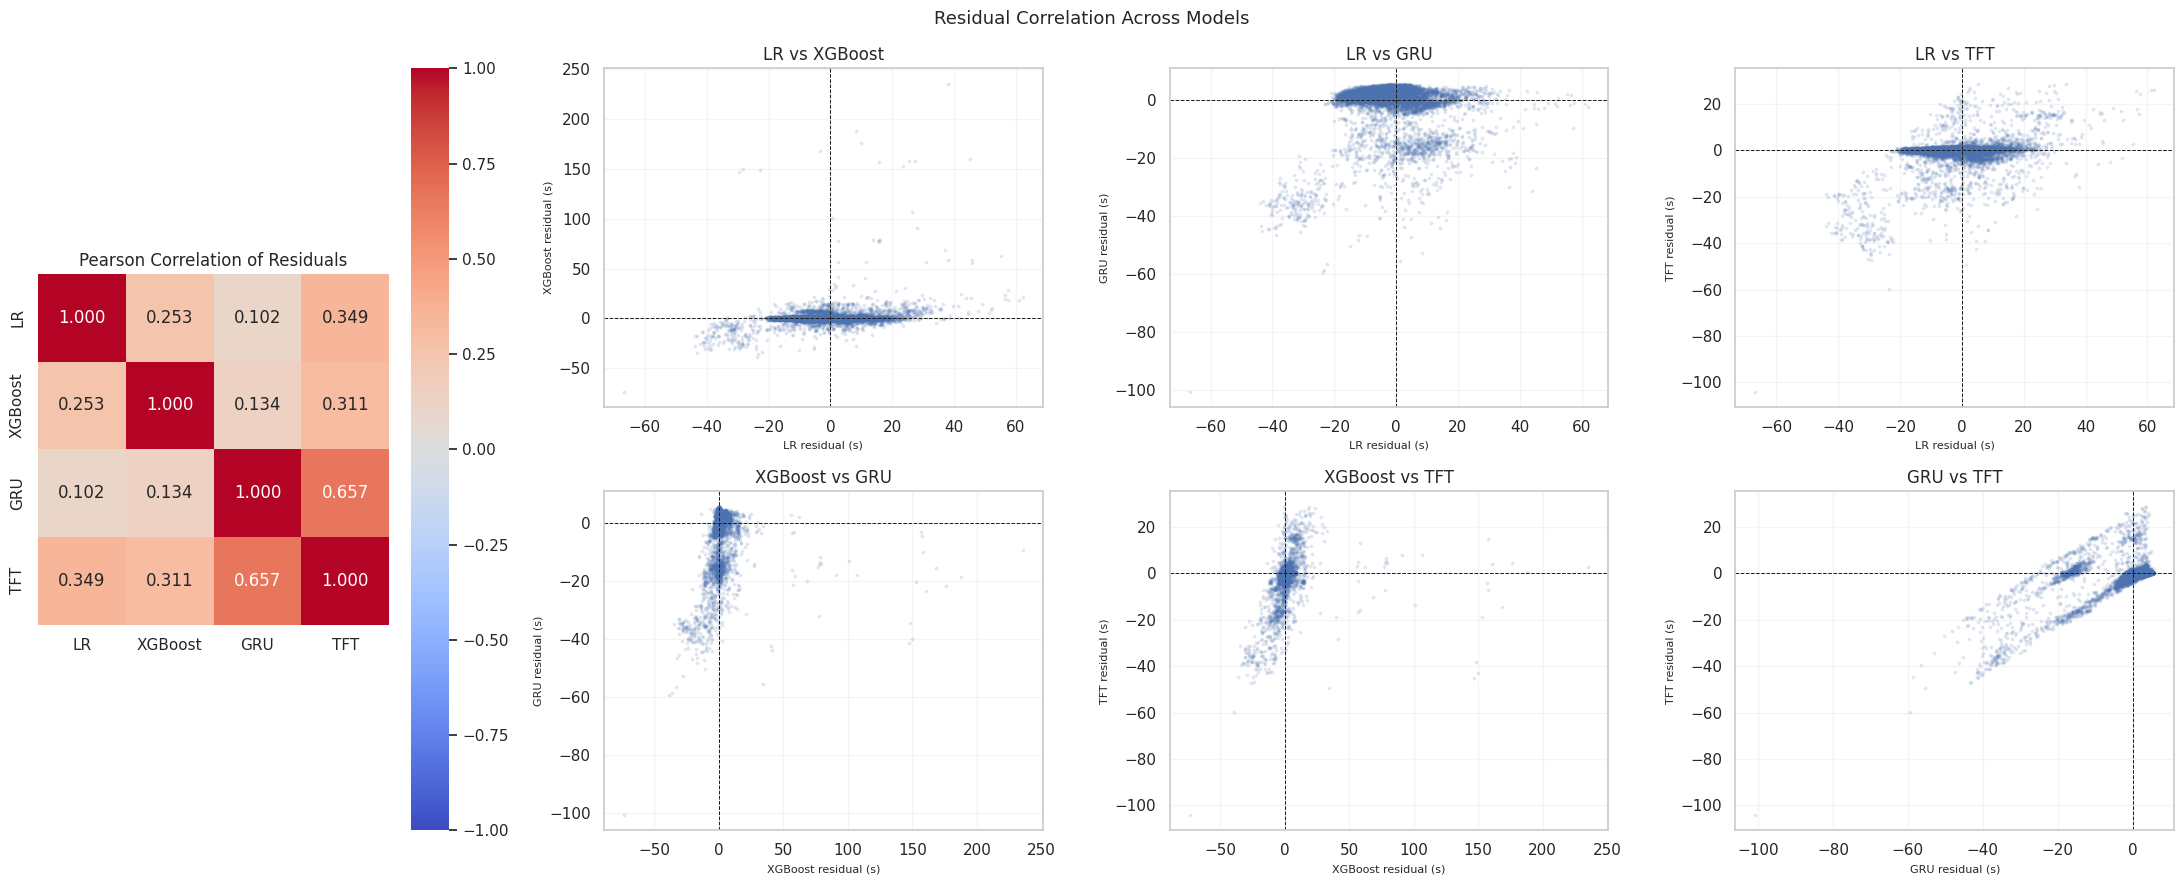

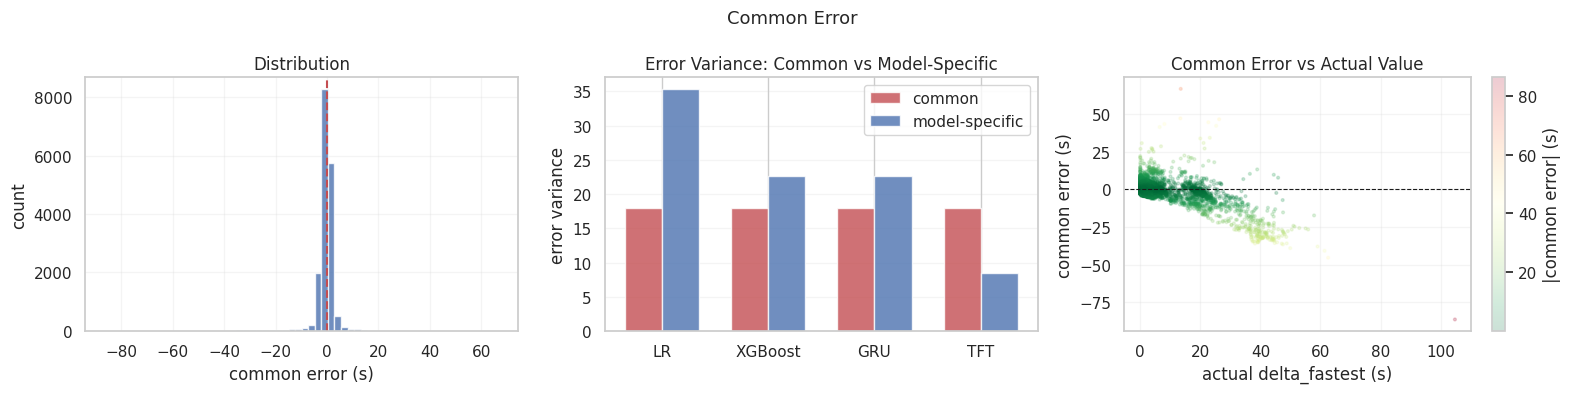

In [14]:
from itertools import combinations

common_mask = df_preds[["resid_lr", "resid_xgb", "resid_gru", "resid_tft"]].notna().all(axis=1)
df_common = df_preds[common_mask].reset_index(drop=True)

resid_matrix = df_common[["resid_lr", "resid_xgb", "resid_gru", "resid_tft"]].copy()
resid_matrix.columns = ["LR", "XGBoost", "GRU", "TFT"]
model_labels = resid_matrix.columns.tolist()
pairs = list(combinations(model_labels, 2))

common_err = resid_matrix.mean(axis=1)
specific_err = resid_matrix.sub(common_err, axis=0)

fig = plt.figure(figsize=(22, 9))
fig.suptitle("Residual Correlation Across Models", fontsize=13)

ax_heat = fig.add_subplot(2, 4, (1, 5))
corr = resid_matrix.corr()
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1,
            ax=ax_heat, square=True)
ax_heat.set_title("Pearson Correlation of Residuals")

for slot, (m1, m2) in zip([2, 3, 4, 6, 7, 8], pairs):
    ax = fig.add_subplot(2, 4, slot)
    ax.scatter(resid_matrix[m1], resid_matrix[m2], alpha=0.12, s=3, color="#4c72b0")
    ax.axhline(0, color="k", linewidth=0.7, linestyle="--")
    ax.axvline(0, color="k", linewidth=0.7, linestyle="--")
    ax.set_xlabel(f"{m1} residual (s)", fontsize=8)
    ax.set_ylabel(f"{m2} residual (s)", fontsize=8)
    ax.set_title(f"{m1} vs {m2}")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
fig.savefig(os.path.join(IMAGE_PATH, "residual_correlation.png"), dpi=150, bbox_inches="tight")
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4))
fig2.suptitle("Common Error", fontsize=13)

axes2[0].hist(common_err, bins=60, color="#4c72b0", edgecolor="white", alpha=0.8)
axes2[0].axvline(0, color="#c44e52", linestyle="--", linewidth=1.5)
axes2[0].set_xlabel("common error (s)")
axes2[0].set_ylabel("count")
axes2[0].set_title(
    f"Distribution"
)
axes2[0].grid(True, alpha=0.2)

common_var   = float(common_err.var())
specific_var = specific_err.var()
x = np.arange(len(model_labels))
w = 0.35
axes2[1].bar(x - w/2, [common_var] * len(model_labels), w, label="common", color="#c44e52", alpha=0.8)
axes2[1].bar(x + w/2, specific_var.values, w, label="model-specific", color="#4c72b0", alpha=0.8)
axes2[1].set_xticks(x)
axes2[1].set_xticklabels(model_labels)
axes2[1].set_ylabel("error variance")
axes2[1].set_title("Error Variance: Common vs Model-Specific")
axes2[1].legend()
axes2[1].grid(True, axis="y", alpha=0.2)

if TARGET_COL in df_common.columns:
    sc = axes2[2].scatter(
        df_common[TARGET_COL], common_err,
        c=np.abs(common_err), cmap="RdYlGn_r", alpha=0.2, s=4
    )
    fig2.colorbar(sc, ax=axes2[2], label="|common error| (s)")
    axes2[2].axhline(0, color="k", linewidth=0.8, linestyle="--")
    axes2[2].set_xlabel("actual delta_fastest (s)")
    axes2[2].set_ylabel("common error (s)")
    axes2[2].set_title("Common Error vs Actual Value")
    axes2[2].grid(True, alpha=0.2)

plt.tight_layout()
fig2.savefig(os.path.join(IMAGE_PATH, "common_error.png"), dpi=150, bbox_inches="tight")
plt.show()


## Bias & Variance Analysis

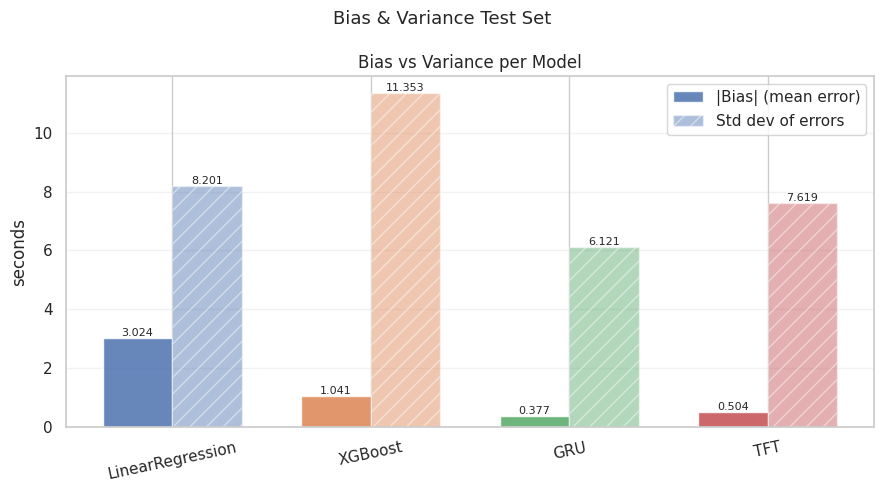

In [15]:

import numpy as np
import matplotlib.pyplot as plt

y_true_full = df_test[TARGET_COL].values

models_preds = {
    "LinearRegression": pred_lr,
    "XGBoost": pred_xgb,
    "GRU": pred_gru,
    "TFT": pred_tft,
}

stats = {}
for name, preds in models_preds.items():
    preds = np.asarray(preds, dtype=float)
    y_true = y_true_full[:len(preds)]
    mask = ~np.isnan(preds)
    resid = preds[mask] - y_true[mask]
    stats[name] = {
        "bias": float(np.mean(resid)),
        "std": float(np.std(resid)),
        "variance": float(np.var(resid)),
        "n": int(mask.sum()),
    }

names = list(stats.keys())
biases = [stats[n]["bias"] for n in names]
stds = [stats[n]["std"] for n in names]
colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52"]

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Bias & Variance Test Set", fontsize=13)

x = np.arange(len(names))
w = 0.35
b1 = ax.bar(x - w/2, np.abs(biases), w, label="|Bias| (mean error)", color=colors, alpha=0.85, edgecolor="white")
b2 = ax.bar(x + w/2, stds, w, label="Std dev of errors", color=colors, alpha=0.45, edgecolor="white", hatch="//")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=12)
ax.set_ylabel("seconds")
ax.set_title("Bias vs Variance per Model")
ax.legend()
ax.grid(True, axis="y", alpha=0.25)
for bar, v in zip(b1, np.abs(biases)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
for bar, v in zip(b2, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f"{v:.3f}", ha="center", va="bottom", fontsize=8)

fig.tight_layout()
plt.show()